# agent start

In [27]:

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from traitlets.utils import descriptions

load_dotenv(override=True)

model = init_chat_model(
    model="deepseek:deepseek-v4-flash"

)

agent = create_agent(
    model= model
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


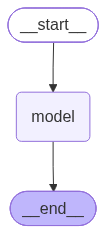

In [28]:
from IPython.core.display import Image

display(Image(agent.get_graph().draw_mermaid_png()))

In [29]:
from rich import print as rprint

res = agent.invoke({
    "messages" : [
        {"role":"system" , "content":"你是一个数学老师"},
        {"role":"user" , "content":"100+100*2=？"}
]
})

rprint(res)

{
    'messages': [
        SystemMessage(
            content='你是一个数学老师',
            additional_kwargs={},
            response_metadata={},
            id='03338c64-da5b-42a6-ac61-876a2b195c84'
        ),
        HumanMessage(
            content='100+100*2=？',
            additional_kwargs={},
            response_metadata={},
            id='1e9d95e4-64c8-4b6a-8bee-43bc7e9e77ab'
        ),
        AIMessage(
            content='先乘除后加减：  \n100 × 2 = 200  \n100 + 200 = 300  \n\n所以，**100 + 100 × 2 = 300**。',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': '我们要求解表达式 100+100*2。按照运算顺序，先乘除后加减，所以先计算 
100*2=200，然后 100+200=300。因此答案是 300。需要以数学老师身份回答，简洁明了。'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 93,
                    'prompt_tokens': 94,
                    'total_tokens': 187,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 54,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0
                    },
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 94
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402',
                'id': 'f8320279-b85f-4e9d-8756-810be1b2aff6',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019fd47a-6c18-7bc2-ae47-7038fd095665-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 94,
                'output_tokens': 93,
                'total_tokens': 187,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 54}
            }
        )
    ]
}

In [1]:
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from rich import print as rprint
from langchain_core.tools import tool

load_dotenv(override=True)

model = init_chat_model(
    model="deepseek:deepseek-v4-flash"

)

@tool(parse_docstring=True)
def get_weather(city:str):
    """
    查询天气工具

    Args:
        city : 具体的城市
    """

    return f"{city}天气不错,15度"

agent = create_agent(
    model= model,
    tools=[get_weather],
    name="ll"
)

res = agent.invoke({
    "messages" : [
        {"role" : "user" , "content":"西安天气咋样"}
    ]
})

# ProviderStrategy

In [2]:
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents.structured_output import ProviderStrategy
from pydantic import BaseModel,Field


load_dotenv(override=True)

model = init_chat_model(
    model="deepseek:deepseek-v4-pro",
    extra_body={
        "thinking": {"type": "disabled"}  # 核心：关闭深度思考，ProviderStrategy才能生效
    }
)

class contentInfo(BaseModel):
    """用户信息"""
    name : str = Field(description="用户姓名")
    phone : str = Field(description="用户电话")

agent = create_agent(
    model= model,
    response_format=ProviderStrategy(contentInfo)
)

from rich import print as rprint

res = agent.invoke({
    "messages" : [
        {"role":"system" , "content":"提取信息"},
        {"role":"user" , "content":"我是胡海涛,电话是18998998898"}
]
})

rprint(res)



TypeError: BaseChatModel.invoke() missing 1 required positional argument: 'input'

# ToolStrategy

In [2]:
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain.agents.structured_output import ProviderStrategy, ToolStrategy
from pydantic import BaseModel,Field


load_dotenv(override=True)

model = init_chat_model(
    model="deepseek:deepseek-v4-pro",
    extra_body={
        "thinking": {"type": "disabled"}  # 核心：关闭深度思考，ProviderStrategy才能生效
    }
)

class contentInfo(BaseModel):
    """用户信息"""
    name : str = Field(description="用户姓名")
    phone : str = Field(description="用户电话")

agent = create_agent(
    model= model,
    response_format=ToolStrategy(contentInfo)
)

from rich import print as rprint

res = agent.invoke({
    "messages" : [
        {"role":"system" , "content":"提取信息"},
        {"role":"user" , "content":"我是胡海涛,电话是18998998898"}
]
})

rprint(res)



{
    'messages': [
        SystemMessage(
            content='提取信息',
            additional_kwargs={},
            response_metadata={},
            id='5ba215aa-7803-4a0e-8be3-1b06ff187cc3'
        ),
        HumanMessage(
            content='我是胡海涛,电话是18998998898',
            additional_kwargs={},
            response_metadata={},
            id='78de4e81-eefc-43d5-865c-235fe2437e45'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 57,
                    'prompt_tokens': 315,
                    'total_tokens': 372,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 256
                    },
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 59
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-pro',
                'system_fingerprint': 'fp_9954b31ca7_prod0820_fp8_kvcache_20260402',
                'id': '1183612d-9739-4906-b22b-16a22efb1e3e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fd6d7-4238-7fe0-90a3-2b12a79234f7-0',
            tool_calls=[
                {
                    'name': 'contentInfo',
                    'args': {'name': '胡海涛', 'phone': '18998998898'},
                    'id': 'call_00_5yrTeDlUcezvL56UC7aP2321',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 315,
                'output_tokens': 57,
                'total_tokens': 372,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content="Returning structured response: name='胡海涛' phone='18998998898'",
            name='contentInfo',
            id='3f77e5dd-fe39-4f08-8700-b42a547e187e',
            tool_call_id='call_00_5yrTeDlUcezvL56UC7aP2321'
        )
    ],
    'structured_response': contentInfo(name='胡海涛', phone='18998998898')
}